In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import import_ipynb

from A_market_model_greeks import *
from B_MDP_state_generator import *
from C_trading_environment import *
from D_quantile_regression import *
from E_actor_critic_networks import *
from F_d4pg_qr_algorithm import ReplayBuffer, train

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [15]:
CONFIG = {
    "env": {
        "r": 0.01,
        "q": 0.0,
        "v": 0.5,
        "rho": -0.3,
        "lambda_day": 1.0,
        "kappa": 0.01,
        "T_days": 30,
        "dt": 1 / 252,
        "T_client_days": 60,
        "T_hedge_days": 30,
        "S0": 100.0,
        "sigma0": 0.2,
    },
    "model": {
        "state_dim": 5,
        "action_dim": 1,
        "M": 100,
        "hidden": 256,
        "n_layers": 3,
    },
    "train": {
        "buffer_capacity": 200_000,
        "batch_size": 256,
        "updates_per_step": 1,
        "gamma": 0.99,
        "tau_soft": 0.005,
        "alpha": 0.95,
        "lambda_std": 1.645,
        "k_huber": 1.0,
        "lr_actor": 1e-4,
        "lr_critic": 1e-4,
        "noise_std": 0.10,
        "warmup_steps": 1_000,
        "maximize_objective": True,
    },
}

OBJECTIVES = ["mean_std", "var", "cvar"]
SEED_BASE = 123
N_EPISODES = 80
N_EVAL = 200


In [16]:
def set_seed(seed):
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


In [17]:
def run_experiment(params, objective, seed, n_episodes):
    """
    Output:
        trained: dict(actor, critic, history)
    """
    set_seed(seed)

    env_params = dict(params["env"])
    model_params = dict(params.get("model", {}))
    train_params = dict(params.get("train", {}))

    env = init_env(env_params, seed=seed)
    state0, _ = env_reset(env, seed=seed)

    state_dim = int(model_params.get("state_dim", len(state0)))
    action_dim = int(model_params.get("action_dim", 1))
    M = int(model_params.get("M", 100))

    actor = build_actor(
        state_dim=state_dim,
        hidden=int(model_params.get("hidden", 256)),
        n_layers=int(model_params.get("n_layers", 3)),
    ).to(DEVICE)

    critic = build_critic_quantile(
        state_dim=state_dim,
        action_dim=action_dim,
        M=M,
    ).to(DEVICE)

    actor_t = build_actor(
        state_dim=state_dim,
        hidden=int(model_params.get("hidden", 256)),
        n_layers=int(model_params.get("n_layers", 3)),
    ).to(DEVICE)

    critic_t = build_critic_quantile(
        state_dim=state_dim,
        action_dim=action_dim,
        M=M,
    ).to(DEVICE)

    buffer = ReplayBuffer(
        capacity=int(train_params.get("buffer_capacity", 200_000)),
        state_dim=state_dim,
        action_dim=action_dim,
    )

    history = train(
        env=env,
        actor=actor,
        critic=critic,
        actor_t=actor_t,
        critic_t=critic_t,
        buffer=buffer,
        n_episodes=int(n_episodes),
        batch_size=int(train_params.get("batch_size", 256)),
        updates_per_step=int(train_params.get("updates_per_step", 1)),
        gamma=float(train_params.get("gamma", 0.99)),
        tau_soft=float(train_params.get("tau_soft", 0.005)),
        objective=objective,
        alpha=float(train_params.get("alpha", 0.95)),
        lambda_std=float(train_params.get("lambda_std", 1.645)),
        k_huber=float(train_params.get("k_huber", 1.0)),
        M=M,
        lr_actor=float(train_params.get("lr_actor", 1e-4)),
        lr_critic=float(train_params.get("lr_critic", 1e-4)),
        noise_std=float(train_params.get("noise_std", 0.10)),
        warmup_steps=int(train_params.get("warmup_steps", 1_000)),
        device=DEVICE,
        maximize_objective=bool(train_params.get("maximize_objective", True)),
    )

    trained = {
        "actor": actor,
        "critic": critic,
        "history": history,
        "objective": objective,
        "seed": int(seed),
    }
    return trained


In [18]:
def evaluate_policy(env, actor, n_eval=200, alpha=0.95):
    """
    Outputs:
        metrics: dict(mean, std, VaR, CVaR, mean_cost)
        samples: np.ndarray (loss samples)
    """
    actor.eval()

    T_days = int(env["params"]["T_days"])
    losses = []
    returns = []
    total_costs = []

    hedge_paths = np.full((int(n_eval), T_days), np.nan, dtype=float)
    cost_paths = np.full((int(n_eval), T_days), np.nan, dtype=float)

    with torch.no_grad():
        for ep in range(int(n_eval)):
            state_np, _ = env_reset(env, seed=100_000 + ep)
            done = False

            ep_return = 0.0
            ep_cost = 0.0
            t = 0

            while not done and t < T_days:
                s_t = torch.tensor(state_np, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                action = float(actor_forward(actor, s_t).cpu().numpy()[0, 0])

                next_state_np, reward, done, info = env_step(env, action)

                reward = float(reward)
                cost = float(info.get("cost", 0.0))
                hedge = float(info.get("H", 0.0))

                ep_return += reward
                ep_cost += cost

                hedge_paths[ep, t] = hedge
                cost_paths[ep, t] = cost

                state_np = next_state_np
                t += 1

            returns.append(ep_return)
            losses.append(-ep_return)
            total_costs.append(ep_cost)

    samples = np.asarray(losses, dtype=float)

    var_alpha = float(np.quantile(samples, alpha))
    tail = samples[samples >= var_alpha]
    cvar_alpha = float(tail.mean()) if tail.size else var_alpha

    metrics = {
        "mean": float(samples.mean()),
        "std": float(samples.std(ddof=0)),
        "VaR": var_alpha,
        "CVaR": cvar_alpha,
        "mean_cost": float(np.mean(total_costs)),
        "mean_return": float(np.mean(returns)),
        "hedge_profile": np.nanmean(hedge_paths, axis=0),
        "hedge_abs_profile": np.nanmean(np.abs(hedge_paths), axis=0),
        "cost_profile": np.nanmean(cost_paths, axis=0),
    }

    return metrics, samples


In [19]:
def _as_history_dict(history):
    if "returns" in history:
        return {"run": history}
    return history


def plot_training_curves(history):
    hdict = _as_history_dict(history)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for name, h in hdict.items():
        axes[0].plot(h["returns"], label=name)
        axes[1].plot(h["actor_loss"], label=name)
        axes[2].plot(h["critic_loss"], label=name)

    axes[0].set_title("Episode returns")
    axes[1].set_title("Actor loss")
    axes[2].set_title("Critic loss")

    for ax in axes:
        ax.grid(True)
        ax.set_xlabel("step")

    axes[0].set_ylabel("value")

    if len(hdict) > 1:
        for ax in axes:
            ax.legend()

    plt.tight_layout()
    plt.show()


In [20]:
def plot_loss_distribution(samples_dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for name, samples in samples_dict.items():
        s = np.asarray(samples, dtype=float)
        axes[0].hist(s, bins=30, alpha=0.35, density=True, label=name)

        s_sorted = np.sort(s)
        cdf = np.arange(1, len(s_sorted) + 1) / len(s_sorted)
        axes[1].plot(s_sorted, cdf, label=name)

    axes[0].set_title("Loss distribution (hist)")
    axes[0].set_xlabel("episode loss")
    axes[0].set_ylabel("density")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].set_title("Empirical CDF")
    axes[1].set_xlabel("episode loss")
    axes[1].set_ylabel("probability")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [21]:
def plot_hedge_profiles(metrics_dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for name, m in metrics_dict.items():
        axes[0].plot(m["hedge_profile"], label=name)
        axes[1].plot(m["hedge_abs_profile"], label=name)

    axes[0].set_title("Mean hedge profile E[H_t]")
    axes[1].set_title("Mean absolute hedge profile E[|H_t|]")

    for ax in axes:
        ax.set_xlabel("day")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_cost_vs_risk(metrics_dict, risk_key="CVaR"):
    plt.figure(figsize=(6, 5))
    for name, m in metrics_dict.items():
        x = m[risk_key]
        y = m["mean_cost"]
        plt.scatter(x, y, s=80)
        plt.text(x, y, f" {name}")

    plt.title(f"Mean cost vs {risk_key}")
    plt.xlabel(risk_key)
    plt.ylabel("mean_cost")
    plt.grid(True)
    plt.show()


In [22]:
trained_by_objective = {}

for i, objective in enumerate(OBJECTIVES):
    print(f"Training objective={objective}...")
    trained_by_objective[objective] = run_experiment(
        params=CONFIG,
        objective=objective,
        seed=SEED_BASE + i,
        n_episodes=N_EPISODES,
    )


Training objective=mean_std...
[ep 10/80] return=16.1363 buffer=300 c_loss=nan a_loss=nan
[ep 20/80] return=8375.4228 buffer=600 c_loss=nan a_loss=nan
[ep 30/80] return=-13.2072 buffer=900 c_loss=nan a_loss=nan
[ep 40/80] return=-28.6990 buffer=1200 c_loss=415.553466796875 a_loss=-6049.67822265625
[ep 50/80] return=-9.3328 buffer=1500 c_loss=1445.3529052734375 a_loss=-10175.8486328125
[ep 60/80] return=637317.5348 buffer=1800 c_loss=410789.4375 a_loss=-8711575.0
[ep 70/80] return=8068760.3990 buffer=2100 c_loss=2554403.25 a_loss=-15290951.0
[ep 80/80] return=68161687.8620 buffer=2400 c_loss=4695735.0 a_loss=-58923592.0
Training objective=var...
[ep 10/80] return=96.9797 buffer=300 c_loss=nan a_loss=nan
[ep 20/80] return=190.0416 buffer=600 c_loss=nan a_loss=nan
[ep 30/80] return=-31.1050 buffer=900 c_loss=nan a_loss=nan
[ep 40/80] return=759437.7147 buffer=1200 c_loss=577781.4375 a_loss=-6477378.5
[ep 50/80] return=109788958.5998 buffer=1500 c_loss=1824361.875 a_loss=-19578516.0
[ep 60

In [23]:
metrics_by_objective = {}
samples_by_objective = {}

alpha_eval = float(CONFIG["train"]["alpha"])

for i, objective in enumerate(OBJECTIVES):
    eval_env = init_env(CONFIG["env"], seed=10_000 + i)
    metrics, samples = evaluate_policy(
        env=eval_env,
        actor=trained_by_objective[objective]["actor"],
        n_eval=N_EVAL,
        alpha=alpha_eval,
    )
    metrics_by_objective[objective] = metrics
    samples_by_objective[objective] = samples

print()
print("Evaluation summary (loss-based):")
print("objective    mean      std       VaR       CVaR      mean_cost")
for objective in OBJECTIVES:
    m = metrics_by_objective[objective]
    print(
        f"{objective:<10} {m['mean']:>8.4f} {m['std']:>8.4f} {m['VaR']:>9.4f} "
        f"{m['CVaR']:>9.4f} {m['mean_cost']:>11.4f}"
    )



Evaluation summary (loss-based):
objective    mean      std       VaR       CVaR      mean_cost
mean_std   -549540938.6216 715035446.1494 -249443.5014 -18617.2608 5335577.9767
var        -549540938.6216 715035446.1494 -249443.5014 -18617.2608 5335577.9767
cvar       -549540938.6216 715035446.1494 -249443.5014 -18617.2608 5335577.9767


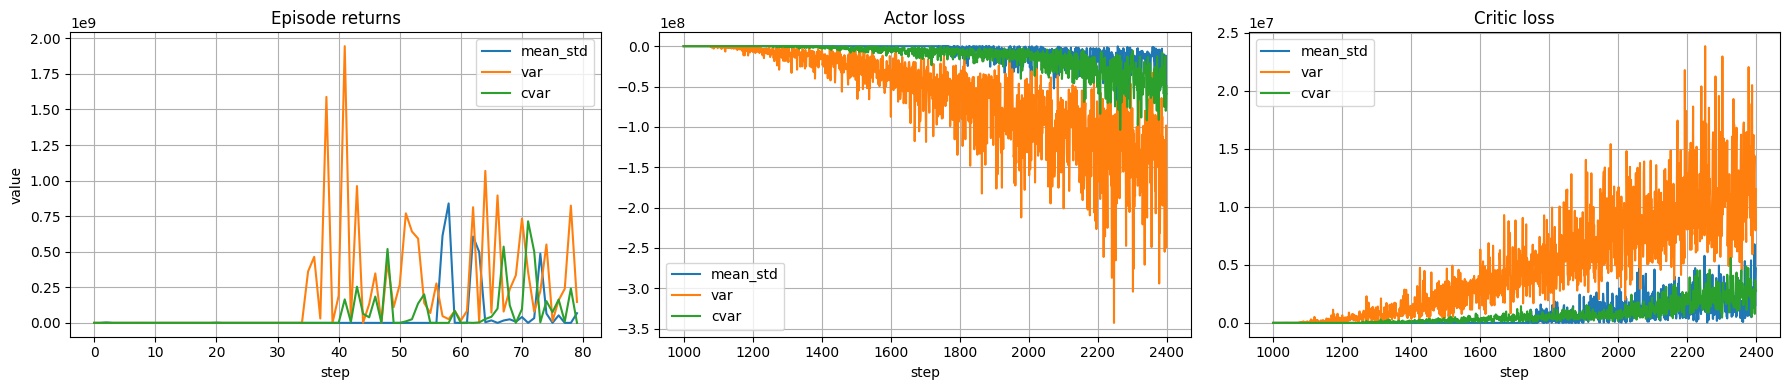

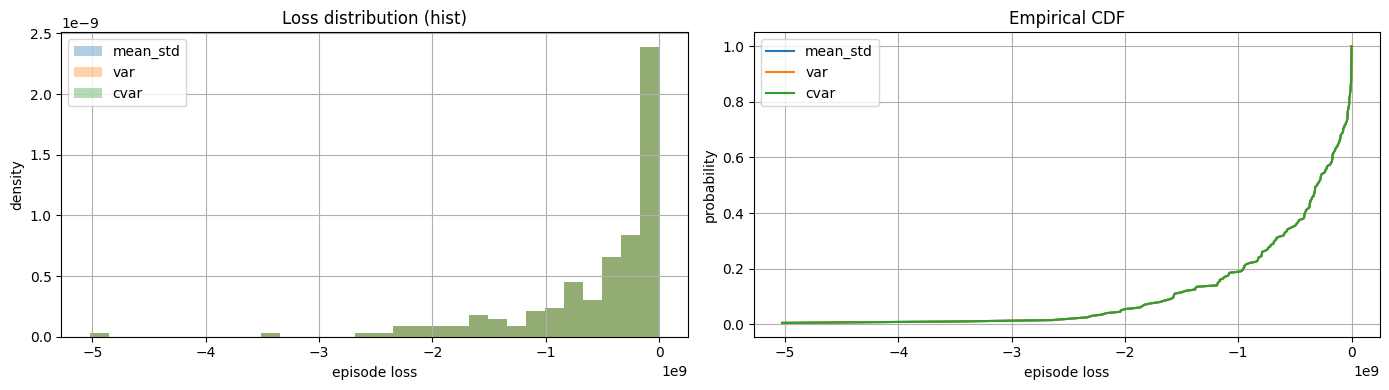

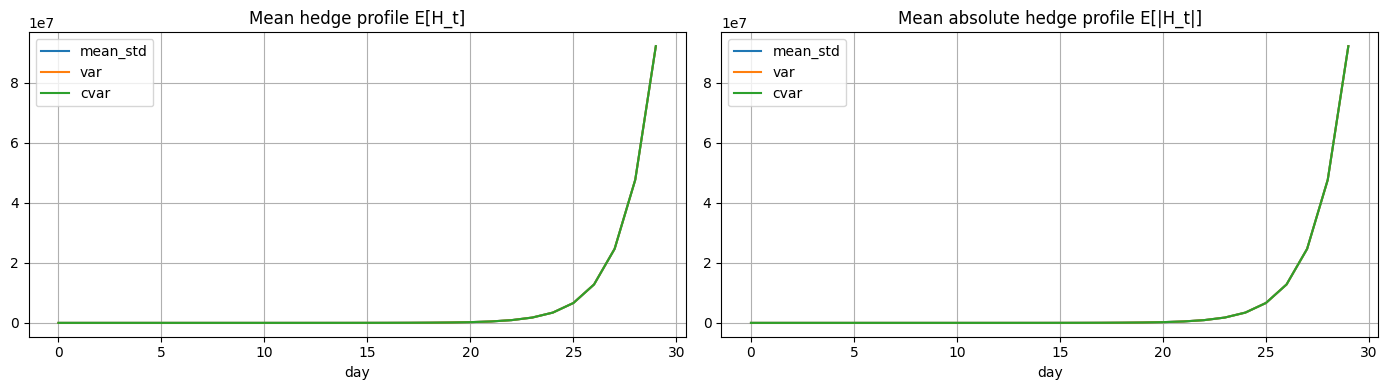

In [26]:
plot_training_curves({k: v["history"] for k, v in trained_by_objective.items()})
plot_loss_distribution(samples_by_objective)
plot_hedge_profiles(metrics_by_objective)
